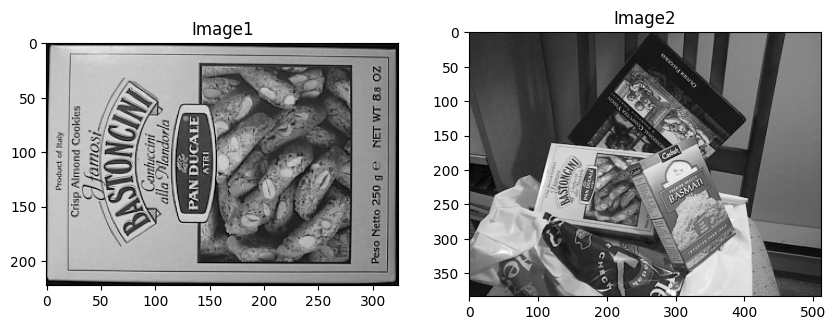

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
img1 = cv2.imread('images/box.png')
img2 = cv2.imread('images/box_in_scene.png') 

plt.figure(figsize=[10,5])
plt.subplot(121),plt.imshow(img1[...,::-1]),plt.title('Image1');
plt.subplot(122),plt.imshow(img2[...,::-1]),plt.title('Image2');

In [2]:
# Initiate SIFT detector
sift = cv2.SIFT_create()
# find the keypoints and descriptors with ORB
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

In [3]:
print(des1.shape)
print(des2.shape)

(604, 128)
(969, 128)


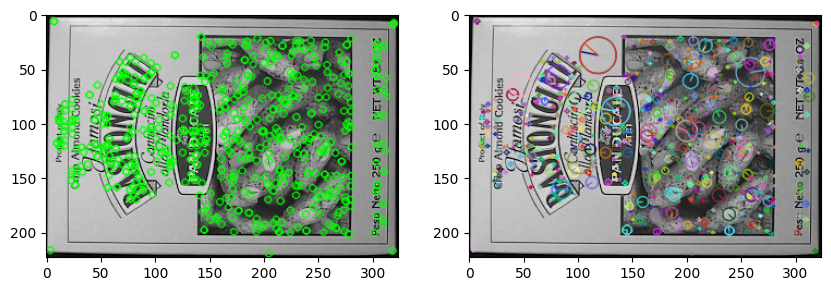

In [4]:
keypoints_without_size = np.copy(img1)
keypoints_with_size = np.copy(img1)

cv2.drawKeypoints(img1, kp1, keypoints_without_size, color = (0, 255, 0))
cv2.drawKeypoints(img1, kp1, keypoints_with_size, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


plt.figure(figsize=[10,5])
plt.subplot(121),plt.imshow(keypoints_without_size[...,::-1]);
plt.subplot(122),plt.imshow(keypoints_with_size[...,::-1]);

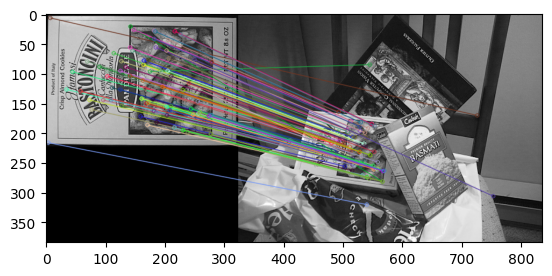

(<matplotlib.image.AxesImage at 0x1181c4390>, None)

In [6]:
# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck = False)

# Match descriptors.
matches = bf.knnMatch(des1,des2,k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append([m])
        
# cv.drawMatchesKnn expects list of lists as matches.
img3 = cv2.drawMatchesKnn(img1,kp1,img2,kp2,good,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img3),plt.show()